### Importing the Data 

In [1]:
import pandas as pd 
import numpy as np 

providers = pd.read_csv('../data/providers_data.csv')
receivers = pd.read_csv('../data/receivers_data.csv')
food_listing = pd.read_csv('../data/food_listings_data.csv')
claims = pd.read_csv('../data/claims_data.csv')
providers.head()


,Provider_ID,Name,Type,Address,City,Contact
0,1,Gonzales-Cochran,Supermarket,"74347 Christopher Extensions\nAndreamouth, OK ...",New Jessica,+1-600-220-0480
1,2,"Nielsen, Johnson and Fuller",Grocery Store,"91228 Hanson Stream\nWelchtown, OR 27136",East Sheena,+1-925-283-8901x6297
2,3,Miller-Black,Supermarket,"561 Martinez Point Suite 507\nGuzmanchester, W...",Lake Jesusview,001-517-295-2206
3,4,"Clark, Prince and Williams",Grocery Store,"467 Bell Trail Suite 409\nPort Jesus, IA 61188",Mendezmouth,556.944.8935x401
4,5,Coleman-Farley,Grocery Store,"078 Matthew Creek Apt. 319\nSaraborough, MA 53978",Valentineside,193.714.6577


In [2]:
provider_null = providers.isnull().sum()
receiver_null = receivers.isnull().sum()
food_listing_null = food_listing.isnull().sum()
claims_null = claims.isnull().sum()

# Combine null counts into a single aligned table.
null_summary = pd.concat(
    [provider_null, receiver_null, food_listing_null, claims_null],
    axis=1,
    keys=["providers", "receivers", "food_listing", "claims"],
).fillna(0).astype(int)

display(null_summary)

,providers,receivers,food_listing,claims
Provider_ID,0,0,0,0
Name,0,0,0,0
Type,0,0,0,0
Address,0,0,0,0
City,0,0,0,0
Contact,0,0,0,0
Receiver_ID,0,0,0,0
Food_ID,0,0,0,0
Food_Name,0,0,0,0
Quantity,0,0,0,0


In [3]:
provider_type = providers.dtypes
receiver_type = receivers.dtypes
food_listing_type = food_listing.dtypes
claims_type = claims.dtypes

# Combine types into a single aligned table.
dtype_summary = pd.concat(
    [provider_type, receiver_type, food_listing_type, claims_type],
    axis=1,
    keys=["providers", "receivers", "food_listing", "claims"],
).fillna('-')

display(dtype_summary)

,providers,receivers,food_listing,claims
Provider_ID,int64,-,int64,-
Name,object,object,-,-
Type,object,object,-,-
Address,object,-,-,-
City,object,object,-,-
Contact,object,object,-,-
Receiver_ID,-,int64,-,int64
Food_ID,-,-,int64,int64
Food_Name,-,-,object,-
Quantity,-,-,int64,-


In [4]:
claims['Timestamp'] = pd.to_datetime(claims['Timestamp'], errors='coerce')
food_listing['Expiry_Date'] = pd.to_datetime(food_listing['Expiry_Date'], errors='coerce')

In [5]:
providers.drop_duplicates()


,Provider_ID,Name,Type,Address,City,Contact
0,1,Gonzales-Cochran,Supermarket,"74347 Christopher Extensions\nAndreamouth, OK ...",New Jessica,+1-600-220-0480
1,2,"Nielsen, Johnson and Fuller",Grocery Store,"91228 Hanson Stream\nWelchtown, OR 27136",East Sheena,+1-925-283-8901x6297
2,3,Miller-Black,Supermarket,"561 Martinez Point Suite 507\nGuzmanchester, W...",Lake Jesusview,001-517-295-2206
3,4,"Clark, Prince and Williams",Grocery Store,"467 Bell Trail Suite 409\nPort Jesus, IA 61188",Mendezmouth,556.944.8935x401
4,5,Coleman-Farley,Grocery Store,"078 Matthew Creek Apt. 319\nSaraborough, MA 53978",Valentineside,193.714.6577
...,...,...,...,...,...,...
995,996,"Vasquez, Ruiz and Flowers",Restaurant,"84308 Justin Stravenue\nNew Amberside, NE 53447",Williamview,+1-319-378-7627x0682
996,997,Garza-Williams,Catering Service,"08864 Figueroa Radial Suite 948\nJennaberg, AZ...",East Rossside,001-924-441-3963x746
997,998,Novak Group,Grocery Store,"934 Zachary Run\nMelissamouth, WY 02729",Joshuastad,(903)642-1969x3300
998,999,Moody Ltd,Grocery Store,"17580 Ernest Hills\nLake Michaelmouth, OR 56416",Stevenchester,637.300.3664x4880


In [6]:
receivers.drop_duplicates()

,Receiver_ID,Name,Type,City,Contact
0,1,Donald Gomez,Shelter,Port Carlburgh,(955)922-5295
1,2,Laurie Ramos,Individual,Lewisburgh,761.042.1570
2,3,Ashley Mckee,NGO,South Randalltown,691-023-0094x856
3,4,Erika Rose,NGO,South Shaneville,8296491111
4,5,John Romero,Individual,Bakerport,067.491.0154
...,...,...,...,...,...
995,996,Matthew Curtis,Shelter,Lanechester,127-889-4442x1289
996,997,Amanda Cain,NGO,New Steven,+1-001-491-5601x5316
997,998,Theodore Briggs,Individual,South Sandra,930-609-9442x5031
998,999,Cheyenne Ramsey,NGO,Lake Jeffery,001-326-320-4816x15300


In [7]:
food_listing.drop_duplicates()

,Food_ID,Food_Name,Quantity,Expiry_Date,Provider_ID,Provider_Type,Location,Food_Type,Meal_Type
0,1,Bread,43,2025-03-17,110,Grocery Store,South Kellyville,Non-Vegetarian,Breakfast
1,2,Soup,22,2025-03-24,791,Grocery Store,West James,Non-Vegetarian,Dinner
2,3,Fruits,46,2025-03-28,478,Catering Service,Lake Regina,Vegan,Breakfast
3,4,Fruits,15,2025-03-16,930,Restaurant,Kellytown,Vegan,Lunch
4,5,Soup,14,2025-03-19,279,Restaurant,Garciaport,Vegan,Dinner
...,...,...,...,...,...,...,...,...,...
995,996,Fish,15,2025-03-30,467,Catering Service,Phillipsfort,Vegan,Breakfast
996,997,Fish,22,2025-03-18,35,Grocery Store,Andersonmouth,Vegetarian,Breakfast
997,998,Fruits,6,2025-03-22,444,Restaurant,New Billy,Non-Vegetarian,Dinner
998,999,Pasta,15,2025-03-30,702,Supermarket,Lake Mistyton,Non-Vegetarian,Lunch


In [8]:
claims.drop_duplicates()

,Claim_ID,Food_ID,Receiver_ID,Status,Timestamp
0,1,164,908,Pending,2025-03-05 05:26:00
1,2,353,391,Cancelled,2025-03-11 10:24:00
2,3,626,492,Completed,2025-03-21 00:59:00
3,4,61,933,Cancelled,2025-03-04 09:08:00
4,5,345,229,Pending,2025-03-14 15:17:00
...,...,...,...,...,...
995,996,855,211,Completed,2025-03-13 19:40:00
996,997,980,746,Cancelled,2025-03-17 22:04:00
997,998,832,967,Cancelled,2025-03-13 18:00:00
998,999,917,90,Completed,2025-03-01 15:31:00


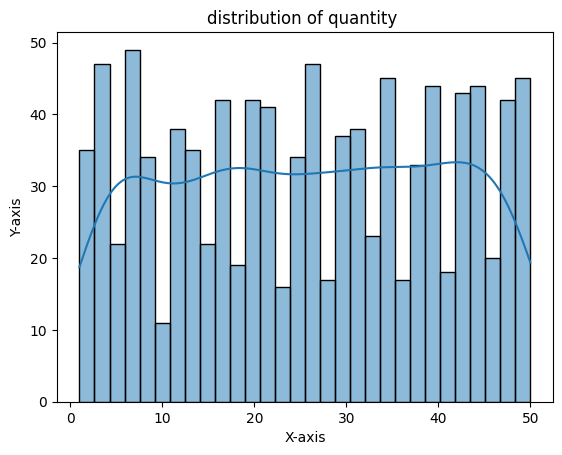

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

Quantity = food_listing['Quantity']
sns.histplot(Quantity, kde=True, bins=30)
plt.title("distribution of quantity ")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.plot()
plt.show()



### Exporting the Cleaned datasets..

In [10]:
# Create cleaned copies (deduplicated) and export them
providers_cleaned = providers.drop_duplicates().copy()
receivers_cleaned = receivers.drop_duplicates().copy()
food_listing_cleaned = food_listing.drop_duplicates().copy()
claims_cleaned = claims.drop_duplicates().copy()

# Export cleaned datasets
providers_cleaned.to_csv('../data/cleaned_data/providers_cleaned.csv', index=False)
receivers_cleaned.to_csv('../data/cleaned_data/receivers_cleaned.csv', index=False)
food_listing_cleaned.to_csv('../data/cleaned_data/food_listings_cleaned.csv', index=False)
claims_cleaned.to_csv('../data/cleaned_data/claims_cleaned.csv', index=False)

print("Cleaned datasets exported to ../data/")

Cleaned datasets exported to ../data/
